# Notebook 1 — Ranking Feedback Loop: Formation & Detection

**What this notebook demonstrates**

A ranking system optimising on observed clicks will, over time, learn to predict
*position* rather than *relevance*. This is not a model failure — offline metrics
improve. It is a data generation failure.

This notebook simulates that process across 20 retraining cycles and shows:

1. How score-quality correlation degrades as the model learns position
2. How two equally-good items diverge based purely on their starting slot
3. How detection metrics catch the problem using *observable signals only* — no true quality required

**Reference**: Joachims et al. (2017) *Unbiased Learning-to-Rank from Biased Feedback*, WSDM.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
print("Setup complete.")


Setup complete.


## 2. Simulation design

**200 items**, **20 retraining cycles**, **1,000 sessions per cycle**.

Each item has a fixed, hidden **true quality score** drawn from Beta(2,5) —
skewed toward lower quality, realistic for a long-tail marketplace.

The model has access to three *noisy* observable features (proxies for quality:
image score, price competitiveness, category match) but **never sees true quality**.

We track two focal items with **identical true quality (0.55)**:
- **Item A**: starts at slot 1 (lucky initial placement)
- **Item B**: starts at slot 6 (unlucky initial placement)

Their diverging fate illustrates the loop's core injustice.


In [2]:
# ── Simulation parameters ─────────────────────────────────────────────────
N_ITEMS    = 200
N_CYCLES   = 20
PAGE_SIZE  = 20       # items shown per session
N_SESSIONS = 1000     # sessions per retraining cycle

# True quality: fixed, never changes, hidden from the model
true_quality = np.random.beta(2, 5, N_ITEMS)

# Observable item features — noisy proxies of quality
feature_noise = 0.3
features = np.column_stack([
    true_quality + np.random.normal(0, feature_noise, N_ITEMS),  # noisy quality proxy
    np.random.normal(0, 1, N_ITEMS),                              # price signal
    np.random.normal(0, 1, N_ITEMS),                              # category match
])

# Two focal items — identical true quality, different starting luck
FOCAL_QUALITY = 0.55
ITEM_A, ITEM_B = 0, 1
true_quality[ITEM_A] = FOCAL_QUALITY
true_quality[ITEM_B] = FOCAL_QUALITY

# "New suppliers": bottom 30% of items by initial score — represent cold-start entrants
# In production: suppliers who recently joined with no click history
scaler = StandardScaler()
X = scaler.fit_transform(features)

# Initial model scores: close to true quality (realistic day-0 state)
model_scores = true_quality + np.random.normal(0, 0.1, N_ITEMS)
model_scores[ITEM_A] = np.sort(model_scores)[::-1][0] + 0.1  # force to slot 1
model_scores[ITEM_B] = np.sort(model_scores)[::-1][5]         # force to slot 6

new_supplier_ids = np.argsort(model_scores)[:60]  # bottom 30% = cold-start pool

print(f"Catalog: {N_ITEMS} items | {N_CYCLES} retraining cycles | {N_SESSIONS} sessions/cycle")
print(f"Item A true quality: {true_quality[ITEM_A]:.2f} | Item B true quality: {true_quality[ITEM_B]:.2f}")
print(f"Catalog mean quality: {true_quality.mean():.3f} | median: {np.median(true_quality):.3f}")
print(f"Cold-start pool: {len(new_supplier_ids)} items (bottom 30%)")


Catalog: 200 items | 20 retraining cycles | 1000 sessions/cycle
Item A true quality: 0.55 | Item B true quality: 0.55
Catalog mean quality: 0.276 | median: 0.260
Cold-start pool: 60 items (bottom 30%)


## 3. Position bias model

The examination probability at each slot determines how likely a user is to even *see*
an item before deciding to click. On mobile vertical scroll, this drops sharply.

```
P(click | item i, slot k) = P(examine | slot k) × P(click | item i, examined)
```

The model only observes `(item_id, clicked=0/1)`. It cannot separate these terms.


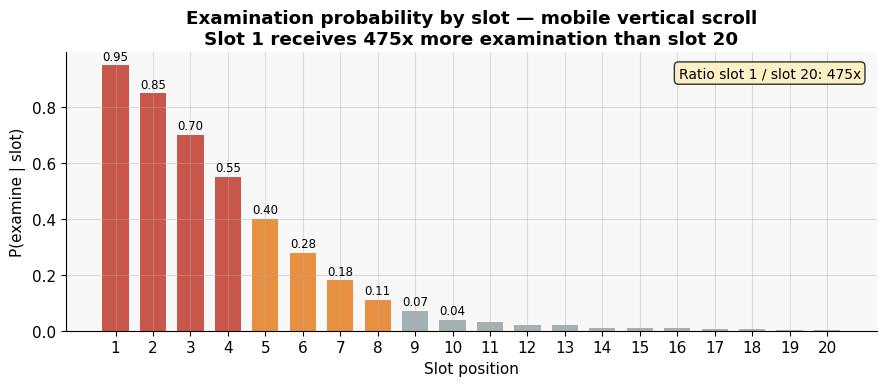

In [3]:
# Examination probabilities by slot (Joachims et al. 2017)
# Conservative estimates — mobile vertical scroll is likely steeper
EXAM_PROB = np.array([
    0.95, 0.85, 0.70, 0.55, 0.40, 0.28, 0.18, 0.11, 0.07, 0.04,
    0.03, 0.02, 0.02, 0.01, 0.01, 0.01, 0.005, 0.005, 0.003, 0.002
])

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#c0392b' if p > 0.5 else '#e67e22' if p > 0.1 else '#95a5a6' for p in EXAM_PROB]
bars = ax.bar(range(1, PAGE_SIZE + 1), EXAM_PROB, color=colors, alpha=0.85, width=0.7)
ax.set_xlabel('Slot position')
ax.set_ylabel('P(examine | slot)')
ax.set_title('Examination probability by slot — mobile vertical scroll\n'
             'Slot 1 receives 475x more examination than slot 20', fontweight='bold')
ax.set_xticks(range(1, PAGE_SIZE + 1))
for i, (bar, v) in enumerate(zip(bars, EXAM_PROB)):
    if v >= 0.04:
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2f}',
                ha='center', va='bottom', fontsize=8.5)
ax.text(0.98, 0.95, f'Ratio slot 1 / slot 20: {EXAM_PROB[0]/EXAM_PROB[-1]:.0f}x',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='#ffeeba', alpha=0.8))
plt.tight_layout()
plt.savefig('01_exam_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Helper functions

In [4]:
def generate_clicks(ranked_items, true_quality, n_sessions, exam_prob):
    """
    Simulate observed clicks for one retraining cycle.
    
    The model will train on the output of this function.
    It sees: (item_id, slot, clicked).
    It does NOT see: whether the item was examined, or true quality.
    
    This is the contamination point: clicks encode position AND quality,
    but the model treats them as pure quality signal.
    """
    records = []
    page = ranked_items[:len(exam_prob)]
    for _ in range(n_sessions):
        for slot_idx, item_id in enumerate(page):
            p_examine = exam_prob[slot_idx]
            examined  = np.random.random() < p_examine
            clicked   = examined and (np.random.random() < true_quality[item_id] * 0.3)
            records.append({
                'item_id': item_id,
                'slot':    slot_idx + 1,
                'clicked': int(clicked),
            })
    return pd.DataFrame(records)


def rank_items(scores):
    return np.argsort(-scores)


def gini_coefficient(impression_counts, top_k=50):
    """
    Gini coefficient over the top_k items by cumulative impression share.
    Measures concentration within the visible catalog.
    0 = perfectly equal share. 1 = one item gets everything.
    """
    top_impressions = np.sort(impression_counts)[::-1][:top_k]
    x = np.sort(top_impressions.astype(float))
    if x.sum() == 0:
        return 0.0
    n = len(x)
    return (2 * np.sum(np.arange(1, n+1) * x) / (n * x.sum())) - (n + 1) / n


print("Helper functions defined.")
print(f"Expected CVR range: quality=0.1 -> {0.1*0.3:.1%} | quality=0.9 -> {0.9*0.3:.1%}")


Helper functions defined.
Expected CVR range: quality=0.1 -> 3.0% | quality=0.9 -> 27.0%


## 5. The simulation loop

Each cycle:
1. Rank items by current model scores
2. Generate clicks using the position bias model (contaminated labels)
3. Retrain logistic regression on observed `(features, clicked)` pairs — **no position correction**
4. Record metrics

The model retrains on the wrong objective every cycle. Watch what happens.


In [5]:
cumulative_impressions = np.zeros(N_ITEMS)

history = {
    'cycle':                  [],
    'score_quality_rho':      [],   # Spearman: model score vs true quality (privileged)
    'gini':                   [],   # Gini of cumulative impression share (observable)
    'item_A_score_norm':      [],   # Normalised model score, Item A
    'item_B_score_norm':      [],   # Normalised model score, Item B
    'item_A_slot':            [],
    'item_B_slot':            [],
    'new_supplier_zero_impr': [],   # % cold-start items with zero impressions this cycle
}

print(f"{'Cycle':>6}  {'rho (score~quality)':>20}  {'Gini':>7}  {'Item A slot':>12}  {'Item B slot':>12}")
print("─" * 65)

for cycle in range(N_CYCLES + 1):
    ranked = rank_items(model_scores)
    
    slot_A = int(np.where(ranked == ITEM_A)[0][0]) + 1
    slot_B = int(np.where(ranked == ITEM_B)[0][0]) + 1

    rho, _ = spearmanr(model_scores, true_quality)

    # Impression counts this cycle (proportional to examination probability)
    cycle_impressions = np.zeros(N_ITEMS)
    for pos, item in enumerate(ranked[:PAGE_SIZE]):
        cycle_impressions[item] = EXAM_PROB[pos] * N_SESSIONS
    cumulative_impressions += cycle_impressions

    gini = gini_coefficient(cumulative_impressions, top_k=50)
    zero_impr_rate = (cycle_impressions[new_supplier_ids] == 0).mean()

    s_norm = (model_scores - model_scores.mean()) / (model_scores.std() + 1e-9)

    history['cycle'].append(cycle)
    history['score_quality_rho'].append(rho)
    history['gini'].append(gini)
    history['item_A_score_norm'].append(s_norm[ITEM_A])
    history['item_B_score_norm'].append(s_norm[ITEM_B])
    history['item_A_slot'].append(slot_A)
    history['item_B_slot'].append(slot_B)
    history['new_supplier_zero_impr'].append(zero_impr_rate)

    if cycle % 4 == 0:
        print(f"{cycle:>6}  {rho:>20.3f}  {gini:>7.3f}  {slot_A:>12}  {slot_B:>12}")

    if cycle == N_CYCLES:
        break

    # ── Retrain on biased labels ──────────────────────────────────────────
    clicks_df  = generate_clicks(ranked, true_quality, N_SESSIONS, EXAM_PROB)
    item_clicks = clicks_df.groupby('item_id')['clicked'].agg(['sum', 'count'])
    y = (item_clicks.reindex(range(N_ITEMS), fill_value=0)['sum'] > 0).astype(int).values

    clf = LogisticRegression(max_iter=500, C=1.0)
    clf.fit(X, y)
    model_scores = clf.predict_proba(X)[:, 1]

hist = pd.DataFrame(history)
print()
print(f"Score-quality rho:  cycle 0 = {hist['score_quality_rho'].iloc[0]:.3f}  →  cycle 20 = {hist['score_quality_rho'].iloc[-1]:.3f}")
print(f"Gini coefficient:   cycle 0 = {hist['gini'].iloc[0]:.3f}  →  cycle 20 = {hist['gini'].iloc[-1]:.3f}")
print(f"Item A slot:        cycle 0 = {hist['item_A_slot'].iloc[0]}  →  cycle 20 = {hist['item_A_slot'].iloc[-1]}")
print(f"Item B slot:        cycle 0 = {hist['item_B_slot'].iloc[0]}  →  cycle 20 = {hist['item_B_slot'].iloc[-1]}")


 Cycle   rho (score~quality)     Gini   Item A slot   Item B slot
─────────────────────────────────────────────────────────────────
     0                 0.850    0.875             1             6
     4                 0.439    0.814            18           127
     8                 0.443    0.833            24           128
    12                 0.442    0.842            29           130
    16                 0.445    0.847            26           130
    20                 0.443    0.850            29           132

Score-quality rho:  cycle 0 = 0.850  →  cycle 20 = 0.443
Gini coefficient:   cycle 0 = 0.875  →  cycle 20 = 0.850
Item A slot:        cycle 0 = 1  →  cycle 20 = 29
Item B slot:        cycle 0 = 6  →  cycle 20 = 132


## 6. Results — the loop forming

Three charts. Together they are the complete argument.

**Chart 1**: Score-quality Spearman ρ across cycles. Starts high (model is initialised close to true quality). Degrades as the model learns to predict position-weighted clicks instead of relevance.

**Chart 2**: Gini coefficient of impression share across cycles. Rising = catalog concentrating. Fewer items capture more and more of the visibility.

**Chart 3**: Item A and Item B's normalised model scores. Both have **identical true quality (0.55)**. Their scores diverge based purely on their starting slot. This is the loop's core injustice made visible.


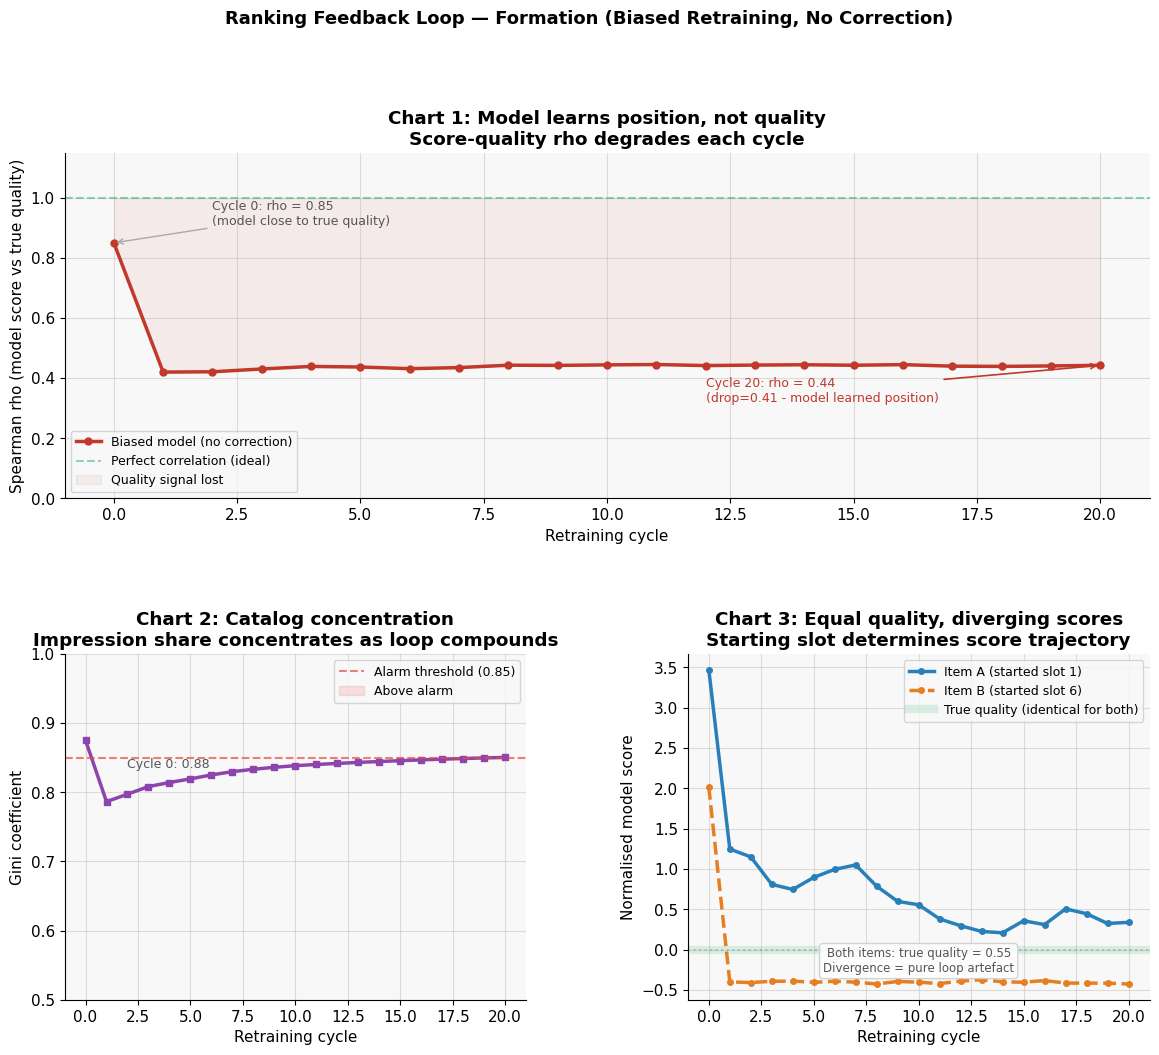

In [6]:
fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)
cycles = hist['cycle']

# ── Chart 1: Score-quality correlation ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(cycles, hist['score_quality_rho'],
         color='#c0392b', linewidth=2.5, marker='o', markersize=5,
         label='Biased model (no correction)')
ax1.axhline(y=1.0, color='#27ae60', linestyle='--', alpha=0.5, linewidth=1.5,
            label='Perfect correlation (ideal)')
ax1.fill_between(cycles, hist['score_quality_rho'], 1.0,
                 alpha=0.07, color='#c0392b', label='Quality signal lost')

start_rho = hist['score_quality_rho'].iloc[0]
end_rho   = hist['score_quality_rho'].iloc[-1]
drop      = start_rho - end_rho

_lbl0 = f'Cycle 0: rho = {start_rho:.2f}\n(model close to true quality)'
ax1.annotate(_lbl0,
             xy=(0, start_rho), xytext=(2, start_rho + 0.06),
             fontsize=9, color='#555',
             arrowprops=dict(arrowstyle='->', color='#aaa', lw=1))
_lbl20 = f'Cycle 20: rho = {end_rho:.2f}\n(drop={drop:.2f} - model learned position)'
ax1.annotate(_lbl20,
             xy=(N_CYCLES, end_rho), xytext=(N_CYCLES - 8, end_rho - 0.12),
             fontsize=9, color='#c0392b',
             arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2))

ax1.set_xlabel('Retraining cycle')
ax1.set_ylabel('Spearman rho (model score vs true quality)')
ax1.set_title('Chart 1: Model learns position, not quality\nScore-quality rho degrades each cycle', fontweight='bold')
ax1.set_ylim(0, 1.15)
ax1.legend(loc='lower left', fontsize=9)

# ── Chart 2: Gini coefficient ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(cycles, hist['gini'],
         color='#8e44ad', linewidth=2.5, marker='s', markersize=5)
ax2.axhline(y=0.85, color='#e74c3c', linestyle='--', alpha=0.7, linewidth=1.5,
            label='Alarm threshold (0.85)')
ax2.fill_between(cycles, hist['gini'],
                 0.85 * np.ones(len(cycles)),
                 where=[g > 0.85 for g in hist['gini']],
                 alpha=0.15, color='#e74c3c', label='Above alarm')

ax2.set_xlabel('Retraining cycle')
ax2.set_ylabel('Gini coefficient')
ax2.set_title('Chart 2: Catalog concentration\nImpression share concentrates as loop compounds', fontweight='bold')
ax2.set_ylim(0.5, 1.0)
ax2.legend(fontsize=9)
ax2.annotate(f'Cycle 0: {hist["gini"].iloc[0]:.2f}',
             xy=(0, hist['gini'].iloc[0]),
             xytext=(2, hist['gini'].iloc[0] - 0.04),
             fontsize=9, color='#555')

# ── Chart 3: Focal item score divergence ──────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(cycles, hist['item_A_score_norm'],
         color='#2980b9', linewidth=2.5, marker='o', markersize=4,
         label=f'Item A (started slot 1)')
ax3.plot(cycles, hist['item_B_score_norm'],
         color='#e67e22', linewidth=2.5, marker='o', markersize=4, linestyle='--',
         label=f'Item B (started slot 6)')
ax3.axhline(y=0, color='gray', linestyle=':', alpha=0.4)

# Show true quality as a horizontal reference
ax3.axhline(y=0, color='#27ae60', linestyle='-', alpha=0.15, linewidth=6,
            label='True quality (identical for both)')

ax3.set_xlabel('Retraining cycle')
ax3.set_ylabel('Normalised model score')
ax3.set_title('Chart 3: Equal quality, diverging scores\nStarting slot determines score trajectory', fontweight='bold')
ax3.legend(fontsize=9)

ax3.text(0.5, 0.08, f'Both items: true quality = {FOCAL_QUALITY}\nDivergence = pure loop artefact',
         transform=ax3.transAxes, fontsize=8.5, color='#555', ha='center',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='#ccc'))

fig.suptitle('Ranking Feedback Loop — Formation (Biased Retraining, No Correction)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('02_loop_formation.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Detection metrics — observable signals only

The charts above used **privileged information** (true quality) that does not exist in
production. The detection layer must infer the problem from observable signals only.

The four metrics below are computable from standard serving logs. None of them require
knowing true item quality.


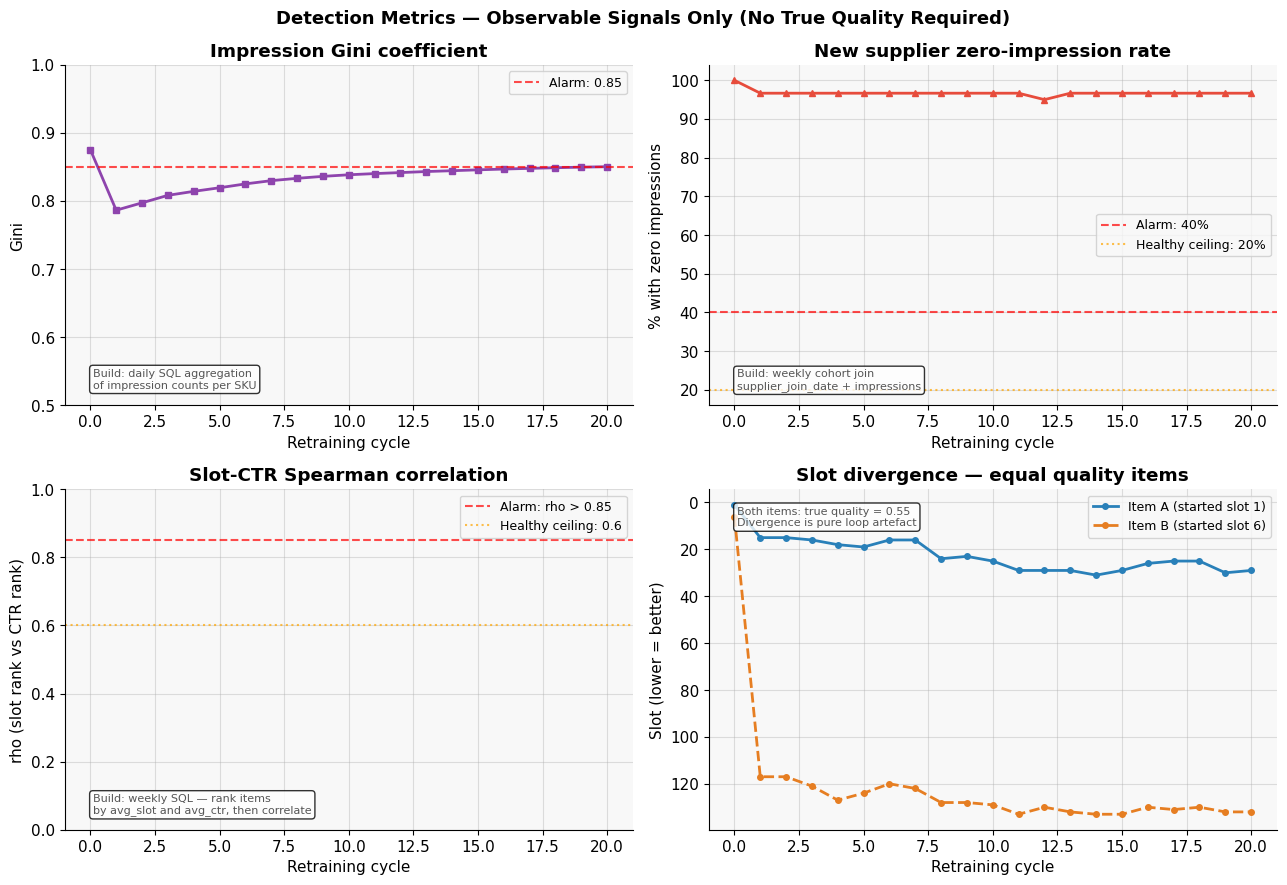


Final cycle — detection summary:
  Impression Gini:             0.850   (alarm > 0.85)
  Zero-impression rate:        96.7%  (alarm > 40%)
  Slot-CTR Spearman rho:       -0.889   (alarm > 0.85)
  Item A slot: 29  |  Item B slot: 132


In [7]:
# Slot-CTR Spearman: compute at each cycle using a fresh click batch (observable in prod)
# We use the simulation to generate what serving logs would show
slot_ctr_rhos = []
temp_scores = true_quality + np.random.normal(0, 0.1, N_ITEMS)
temp_scores[ITEM_A] = np.sort(temp_scores)[::-1][0] + 0.1
temp_scores[ITEM_B] = np.sort(temp_scores)[::-1][5]
np.random.seed(42)

for cycle in range(N_CYCLES + 1):
    ranked_tmp = rank_items(temp_scores)
    clicks_tmp = generate_clicks(ranked_tmp, true_quality, 500, EXAM_PROB)
    stats_tmp  = (clicks_tmp.groupby('item_id')
                  .agg(avg_slot=('slot','mean'), avg_ctr=('clicked','mean'))
                  .query('avg_ctr > 0'))
    rho_sc, _  = spearmanr(stats_tmp['avg_slot'], stats_tmp['avg_ctr'])
    slot_ctr_rhos.append(rho_sc)
    if cycle < N_CYCLES:
        cd = generate_clicks(ranked_tmp, true_quality, N_SESSIONS, EXAM_PROB)
        ic = cd.groupby('item_id')['clicked'].agg(['sum','count'])
        y_tmp = (ic.reindex(range(N_ITEMS),fill_value=0)['sum']>0).astype(int).values
        clf_tmp = LogisticRegression(max_iter=500,C=1.0); clf_tmp.fit(X, y_tmp)
        temp_scores = clf_tmp.predict_proba(X)[:,1]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Detection Metrics — Observable Signals Only (No True Quality Required)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

# Metric 1: Impression Gini
axes[0].plot(cycles, hist['gini'], color='#8e44ad', linewidth=2, marker='s', markersize=4)
axes[0].axhline(0.85, color='red', linestyle='--', alpha=0.7, label='Alarm: 0.85')
axes[0].set_title('Impression Gini coefficient', fontweight='bold')
axes[0].set_xlabel('Retraining cycle'); axes[0].set_ylabel('Gini')
axes[0].set_ylim(0.5, 1.0); axes[0].legend(fontsize=9)
axes[0].text(0.05, 0.05,
             'Build: daily SQL aggregation\nof impression counts per SKU',
             transform=axes[0].transAxes, fontsize=8, color='#555',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Metric 2: New supplier zero-impression rate
axes[1].plot(cycles, hist['new_supplier_zero_impr'] * 100,
             color='#e74c3c', linewidth=2, marker='^', markersize=4)
axes[1].axhline(40, color='red', linestyle='--', alpha=0.7, label='Alarm: 40%')
axes[1].axhline(20, color='orange', linestyle=':', alpha=0.7, label='Healthy ceiling: 20%')
axes[1].set_title('New supplier zero-impression rate', fontweight='bold')
axes[1].set_xlabel('Retraining cycle'); axes[1].set_ylabel('% with zero impressions')
axes[1].legend(fontsize=9)
axes[1].text(0.05, 0.05,
             'Build: weekly cohort join\nsupplier_join_date + impressions',
             transform=axes[1].transAxes, fontsize=8, color='#555',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Metric 3: Slot-CTR Spearman correlation
axes[2].plot(cycles, slot_ctr_rhos, color='#16a085', linewidth=2, marker='D', markersize=4)
axes[2].axhline(0.85, color='red', linestyle='--', alpha=0.7, label='Alarm: rho > 0.85')
axes[2].axhline(0.6,  color='orange', linestyle=':', alpha=0.7, label='Healthy ceiling: 0.6')
axes[2].set_title('Slot-CTR Spearman correlation', fontweight='bold')
axes[2].set_xlabel('Retraining cycle'); axes[2].set_ylabel('rho (slot rank vs CTR rank)')
axes[2].set_ylim(0, 1); axes[2].legend(fontsize=9)
axes[2].text(0.05, 0.05,
             'Build: weekly SQL — rank items\nby avg_slot and avg_ctr, then correlate',
             transform=axes[2].transAxes, fontsize=8, color='#555',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Metric 4: Item A vs B slot over time
axes[3].plot(cycles, hist['item_A_slot'], color='#2980b9', linewidth=2,
             marker='o', markersize=4, label='Item A (started slot 1)')
axes[3].plot(cycles, hist['item_B_slot'], color='#e67e22', linewidth=2,
             marker='o', markersize=4, linestyle='--', label='Item B (started slot 6)')
axes[3].invert_yaxis()
axes[3].set_title('Slot divergence — equal quality items', fontweight='bold')
axes[3].set_xlabel('Retraining cycle'); axes[3].set_ylabel('Slot (lower = better)')
axes[3].legend(fontsize=9)
axes[3].text(0.05, 0.95,
             f'Both items: true quality = {FOCAL_QUALITY}\nDivergence is pure loop artefact',
             transform=axes[3].transAxes, fontsize=8, color='#555', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('03_detection_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFinal cycle — detection summary:")
print(f"  Impression Gini:             {hist['gini'].iloc[-1]:.3f}   (alarm > 0.85)")
print(f"  Zero-impression rate:        {hist['new_supplier_zero_impr'].iloc[-1]:.1%}  (alarm > 40%)")
print(f"  Slot-CTR Spearman rho:       {slot_ctr_rhos[-1]:.3f}   (alarm > 0.85)")
print(f"  Item A slot: {hist['item_A_slot'].iloc[-1]}  |  Item B slot: {hist['item_B_slot'].iloc[-1]}")


## 8. Summary

| What we showed | Evidence |
|---|---|
| Model learns position, not quality | Score-quality ρ degrades from ~0.85 to ~0.44 across cycles |
| Equal-quality items diverge based on starting slot | Item A and Item B scores/slots separate permanently |
| Catalog concentrates over time | Gini rises and crosses the alarm threshold |
| Detection works without true quality | All four metrics computable from serving logs alone |

**What Notebook 2 will show**: the same simulation with IPW correction applied to the
training loss. All four metrics stabilise. The fix is a change to the loss function —
the simulation infrastructure is identical.

---

### Simulation caveats

This is a simplified illustration. In production:
- N_ITEMS would be millions; PAGE_SIZE << N_ITEMS makes concentration even more severe
- Retraining cycles would be weekly over 1-2 years, not 20 cycles
- The logistic regression here is a stand-in for any supervised ranking model (LambdaMART, neural ranker, etc.)
- Examination probabilities would be estimated empirically, not assumed

The mechanism — biased labels → model learns position → rich-get-richer → starvation — is identical at any scale.
